# 07 — Impulse Response Functions: how shocks propagate

The previous notebooks showed that `BayesianVECM` can fit, summarise, and forecast. But forecasting answers *one* question: given what we know, what happens next? The question practitioners using a VECM for brand marketing actually want answered is different: **if brand awareness gets a shock today, what happens to organic sales over the next 52 weeks?**

That question is answered by an **Impulse Response Function (IRF)**. An IRF traces the expected response of every variable in the system to a one-time unit shock in one variable, holding everything else equal at time $h = 0$ and then letting the system evolve freely.

This notebook walks through `BayesianVECM.irf(steps)` and introduces two key ideas:

1. **Why Generalised IRFs (GIRFs) are the right default** for systems with contemporaneous feedback — like brand awareness $\leftrightarrow$ consideration $\leftrightarrow$ organic sales.
2. **Why the IRF doesn't decay to zero** in a cointegrated I(1) system — and why that's economically important for brand marketing.

**Setup:** bivariate cointegrated DGP as in notebooks 04–05, but now we label the variables `"awareness"` and `"sales"` to make the marketing narrative concrete.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bayesian_vecm import BayesianVECM

np.set_printoptions(precision=3, suppress=True)

In [2]:
# ---------------------------------------------------------------------------
# Sampling configuration
# ---------------------------------------------------------------------------
# Set FAST_SAMPLING = True for quick execution (CI / first read-through).
# Set FAST_SAMPLING = False for publication-quality posteriors.
# ---------------------------------------------------------------------------
FAST_SAMPLING = True

if FAST_SAMPLING:
    DRAWS, TUNE, CHAINS = 200, 200, 2
else:
    DRAWS, TUNE, CHAINS = 1000, 1000, 4

print(f"Sampling config: draws={DRAWS}, tune={TUNE}, chains={CHAINS}")
if FAST_SAMPLING:
    print("(FAST_SAMPLING=True — posteriors are coarser; set to False for full quality)")

Sampling config: draws=200, tune=200, chains=2
(FAST_SAMPLING=True — posteriors are coarser; set to False for full quality)


## 1. The DGP: a bivariate brand-awareness / sales system

We use the same bivariate cointegrated DGP as notebooks 04–05 — $\beta = (1, -0.5)^{\top}$, $\alpha = (-0.4, 0.2)^{\top}$ — but now label the two variables as `"awareness"` and `"sales"`. The cointegrating relation is:

$$
\text{awareness}_t - 0.5 \cdot \text{sales}_t \approx 0
$$

meaning awareness and sales are tied together in the long run — brand investment that raises awareness will eventually pull sales up with it. The speed-of-adjustment coefficients $\alpha = (-0.4, 0.2)$ say:

- When awareness is *above* the long-run relationship with sales (positive EC term), awareness is pulled back down ($\alpha_0 = -0.4$).
- When awareness is above the relationship, sales are pushed upward ($\alpha_1 = 0.2$) — this is the error-correction mechanism in action.

We pass the data as a `pandas.DataFrame` with column names so the IRF output carries meaningful coordinate labels.

In [3]:
def make_awareness_sales(
    n_obs: int = 120,
    alpha_true: tuple[float, float] = (-0.4, 0.2),
    beta_true: tuple[float, float] = (1.0, -0.5),
    sigma: float = 0.5,
    seed: int = 0,
) -> pd.DataFrame:
    """Bivariate cointegrated DGP labelled 'awareness' and 'sales'.

    Long-run relation: awareness - 0.5 * sales = 0.
    Speed-of-adjustment: alpha = (-0.4, 0.2).
    """
    rng = np.random.default_rng(seed=seed)
    a0, a1 = alpha_true
    b0, b1 = beta_true
    y = np.zeros((n_obs, 2))
    y[0] = rng.normal(size=2)
    for t in range(1, n_obs):
        ec = b0 * y[t - 1, 0] + b1 * y[t - 1, 1]
        y[t, 0] = y[t - 1, 0] + a0 * ec + rng.normal(scale=sigma)
        y[t, 1] = y[t - 1, 1] + a1 * ec + rng.normal(scale=sigma)
    return pd.DataFrame(y, columns=["awareness", "sales"])


endog_df = make_awareness_sales(n_obs=120, seed=0)
print(f"Shape: {endog_df.shape}")
print(endog_df.tail(3))

Shape: (120, 2)
     awareness     sales
117   1.333666  3.102997
118   0.536543  2.577503
119  -0.715742  1.855922


## 2. Fit the model

Standard fit — nothing new here. We use the full 120 observations; no held-out test set needed for IRF analysis.

In [4]:
model = BayesianVECM(k_ar_diff=1, coint_rank=1, deterministic="n")
model.fit(
    endog_df,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=42,
    progressbar=False,
    cores=1,
)

print("Fit complete.")
print(model.summary())

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_free, Gamma, Sigma_chol]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fit complete.
              mean     sd  eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
alpha[0, 0]   -0.3  0.085     -0.43    -0.16       210       175  1.01   
alpha[1, 0]    0.2  0.092     0.047     0.35       178       217  1.01   
beta[0, 0]       1      0         1        1       400       400   NaN   
beta[1, 0]   -0.45  0.042     -0.52    -0.39       318       220  1.00   
Gamma[0, 0]     -0  0.104     -0.16     0.17       300       198  1.01   
Gamma[0, 1]  0.064  0.086    -0.074      0.2       490       345  1.01   
Gamma[1, 0]  -0.08   0.11     -0.24    0.093       179       178  1.01   
Gamma[1, 1]  0.013  0.079     -0.12     0.15       453       339  1.00   
Sigma[0, 0]  0.254  0.035       0.2     0.32       391       303  1.00   
Sigma[0, 1]  0.035  0.023  -0.00034    0.072       458       351  1.00   
Sigma[1, 0]  0.035  0.023  -0.00034    0.072       458       351  1.00   
Sigma[1, 1]   0.28  0.039      0.22     0.35       289       347  1.00   

            mcse_mean  

/Users/ryanosullivan/Development/bayesian_vecm/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/ryanosullivan/Development/bayesian_vecm/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


## 3. What is a Generalised IRF?

### The standard approach: Cholesky-orthogonalised IRFs (Sims 1980)

The classic approach to computing IRFs is to *orthogonalise* the shocks using a Cholesky decomposition of $\Sigma$. This imposes a recursive (triangular) causal ordering: if you order awareness before sales, then a shock to sales cannot affect awareness contemporaneously. The IRF is then well-defined because the shocks are uncorrelated by construction.

The problem: the ordering assumption is often wrong. **In a brand marketing system, the causal flow has feedback loops.** Awareness drives sales, but sales (word-of-mouth from satisfied customers) also drive awareness. Ordering them either way imposes a zero contemporaneous restriction that doesn't hold.

### The alternative: Generalised IRFs (Pesaran & Shin 1998)

Generalised IRFs (GIRFs) don't require a recursive ordering. Instead of orthogonalising the shocks, they condition on a shock to variable $j$ and integrate out the correlated responses of the other variables using the historical covariance $\Sigma$:

$$
\text{GIRF}_h[:, j]
  = \frac{1}{\sqrt{\sigma_{jj}}} \, \Phi_h \, \Sigma \, e_j
$$

where $\Phi_h$ is the MA coefficient matrix at horizon $h$ (derived from the VAR companion form), $e_j$ is the $j$-th unit vector, and $\sigma_{jj}$ is the variance of variable $j$'s innovation. The $1/\sqrt{\sigma_{jj}}$ scaling makes it a *unit* shock — one standard deviation of variable $j$.

The result: an IRF that is **order-invariant** and doesn't impose any zero restrictions. It is the right default for systems with contemporaneous feedback.

### Computing IRFs from the VECM

Both methods work via the **VAR companion form**. The VECM

$$
\Delta y_t = \alpha\beta^{\top} y_{t-1} + \Gamma_1 \Delta y_{t-1} + \varepsilon_t
$$

is first converted to a levels VAR($p$) with $p = k_{\text{ar\_diff}} + 1 = 2$:

$$
y_t = A_1 y_{t-1} + A_2 y_{t-2} + \varepsilon_t,
\qquad
A_1 = I + \alpha\beta^{\top} + \Gamma_1,
\quad
A_2 = -\Gamma_1.
$$

The companion matrix $F$ stacks the coefficients into a $Kp \times Kp$ block:

$$
F = \begin{pmatrix} A_1 & A_2 \\ I_K & 0 \end{pmatrix}.
$$

The MA coefficients are then $\Phi_h = J F^h J^{\top}$ where $J = [I_K \mid 0]$ selects the first $K$ rows and columns. Since $\Phi_0 = I_K$, the impact response is the identification scheme itself: $\Sigma D^{-1/2}$ for GIRF, $P$ (Cholesky) for OIRFs.

## 4. Compute the posterior GIRF

`model.irf(steps)` returns an `xr.DataArray` of shape
`(chain, draw, horizon, response_variable, shock_variable)`. Every posterior draw gets its own IRF — the result is a full **posterior distribution over IRF paths**.

In [5]:
IRF_STEPS = 40  # 40 periods ahead

girf = model.irf(steps=IRF_STEPS, method="girf")

print(f"GIRF shape : {girf.shape}")
print(f"dims       : {girf.dims}")
print(f"horizon    : {girf.coords['horizon'].values[[0, -1]]} (first, last)")
print(f"response   : {girf.coords['response_variable'].values.tolist()}")
print(f"shock      : {girf.coords['shock_variable'].values.tolist()}")

GIRF shape : (2, 200, 41, 2, 2)
dims       : ('chain', 'draw', 'horizon', 'response_variable', 'shock_variable')
horizon    : [ 0 40] (first, last)
response   : ['awareness', 'sales']
shock      : ['awareness', 'sales']


## 5. IRF fan charts with posterior HDI bands

We plot all four (shock, response) pairs. Each panel shows:

- **Posterior mean** — the central IRF path.
- **80% HDI** (10th–90th percentile) — the core uncertainty range.
- **95% HDI** (2.5th–97.5th percentile) — the wider tails.

The dashed horizontal line at zero is the reference: a response above zero means a positive shock to the shock variable *raises* the response variable.

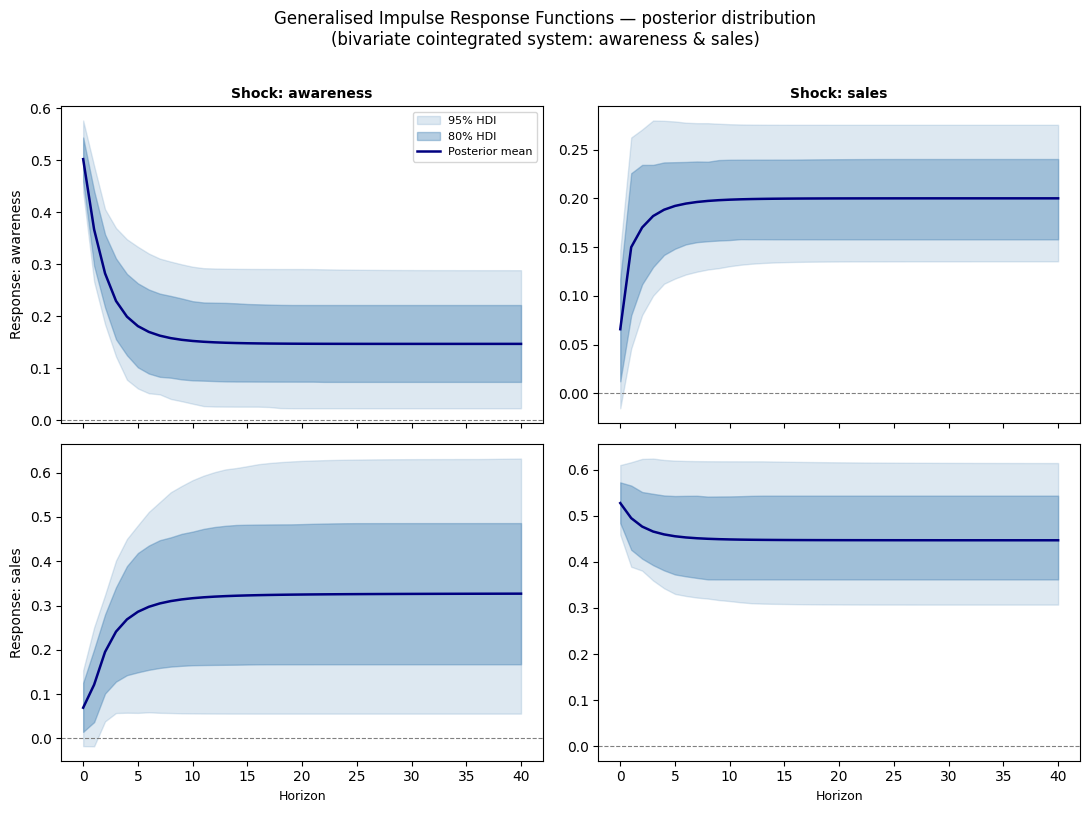

In [6]:
# Flatten (chain, draw) -> draw_total for quantile computation.
n_chains, n_draws_per, n_horizons, n_vars, _ = girf.shape
n_draws_total = n_chains * n_draws_per

# girf_flat: (n_draws_total, horizon, response, shock)
girf_flat = girf.values.reshape(n_draws_total, n_horizons, n_vars, n_vars)

horizons = girf.coords["horizon"].values
var_names = girf.coords["response_variable"].values.tolist()

fig, axes = plt.subplots(n_vars, n_vars, figsize=(11, 8), sharex=True, sharey=False)

for shock_idx, shock_name in enumerate(var_names):
    for resp_idx, resp_name in enumerate(var_names):
        ax = axes[resp_idx, shock_idx]
        paths = girf_flat[:, :, resp_idx, shock_idx]  # (D, H)

        mean_path = paths.mean(axis=0)
        q10 = np.quantile(paths, 0.10, axis=0)
        q90 = np.quantile(paths, 0.90, axis=0)
        q025 = np.quantile(paths, 0.025, axis=0)
        q975 = np.quantile(paths, 0.975, axis=0)

        ax.fill_between(horizons, q025, q975, color="steelblue", alpha=0.18, label="95% HDI")
        ax.fill_between(horizons, q10, q90, color="steelblue", alpha=0.40, label="80% HDI")
        ax.plot(horizons, mean_path, color="navy", linewidth=1.8, label="Posterior mean")
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")

        if resp_idx == 0:
            ax.set_title(f"Shock: {shock_name}", fontsize=10, fontweight="bold")
        if shock_idx == 0:
            ax.set_ylabel(f"Response: {resp_name}", fontsize=10)
        if resp_idx == n_vars - 1:
            ax.set_xlabel("Horizon", fontsize=9)
        if resp_idx == 0 and shock_idx == 0:
            ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    "Generalised Impulse Response Functions — posterior distribution\n"
    "(bivariate cointegrated system: awareness & sales)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

## 6. The I(1) signature: IRFs that don't decay to zero

In a **stationary** VAR (all eigenvalues of the companion matrix inside the unit circle), a shock dies out completely. After enough horizons, the IRF returns to zero — the system forgets the shock.

In a **cointegrated I(1)** system, the companion matrix has unit-root eigenvalues. Shocks have **permanent effects**. The IRF does not return to zero; it settles to a non-zero long-run level that reflects the cointegrating restriction.

**For brand marketing, this is the whole point.** A brand spend campaign that raises awareness by one unit doesn't just give a temporary sales lift — it shifts the long-run level of the awareness/sales relationship. The VECM captures this; a plain VAR-in-differences (which ignores the cointegrating relation) cannot, because it implicitly forces the long-run response to zero.

Let's measure the long-run response directly.

In [7]:
# Compare the response at h=0 and h=40 for each (shock, response) pair.
print("Posterior mean IRF at h=0 vs h=40 (long-run):")
print(f"{'Shock':>12}  {'Response':>12}  {'h=0 mean':>10}  {'h=40 mean':>10}  {'decayed?':>10}")
print("-" * 62)
for shock_idx, shock_name in enumerate(var_names):
    for resp_idx, resp_name in enumerate(var_names):
        paths = girf_flat[:, :, resp_idx, shock_idx]
        h0 = paths[:, 0].mean()
        h_last = paths[:, -1].mean()
        decayed = "yes" if abs(h_last) < 0.01 * abs(h0) else "no — permanent"
        print(f"{shock_name:>12}  {resp_name:>12}  {h0:>10.4f}  {h_last:>10.4f}  {decayed:>10}")

print()
print(
    "Interpretation: in a cointegrated system shocks have permanent effects.\n"
    "The IRF settles to a non-zero long-run level rather than decaying to zero.\n"
    "A plain VAR-in-differences would force this long-run response to exactly zero."
)

Posterior mean IRF at h=0 vs h=40 (long-run):
       Shock      Response    h=0 mean   h=40 mean    decayed?
--------------------------------------------------------------
   awareness     awareness      0.5025      0.1472  no — permanent
   awareness         sales      0.0693      0.3268  no — permanent
       sales     awareness      0.0659      0.2002  no — permanent
       sales         sales      0.5275      0.4468  no — permanent

Interpretation: in a cointegrated system shocks have permanent effects.
The IRF settles to a non-zero long-run level rather than decaying to zero.
A plain VAR-in-differences would force this long-run response to exactly zero.


## 7. GIRF vs Cholesky: why ordering matters

To make the ordering problem concrete, let's compute Cholesky-orthogonalised IRFs under two opposite orderings and compare them to the GIRF.

- **Ordering A:** awareness first, sales second. Assumption: a sales shock cannot affect awareness contemporaneously.
- **Ordering B:** sales first, awareness second. Assumption: an awareness shock cannot affect sales contemporaneously.

We implement this by reordering the rows/columns of the fitted $\Sigma$ before computing the Cholesky IRF, then un-permuting the result.

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_free, Gamma, Sigma_chol]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


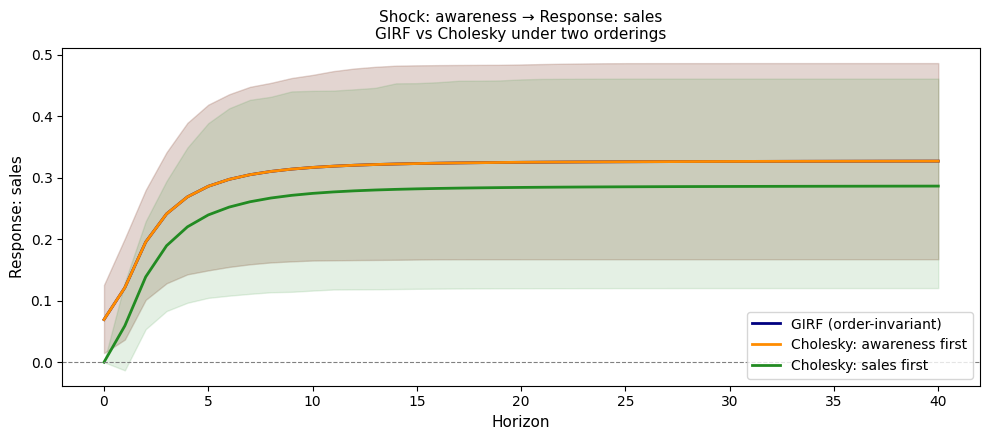

Long-run (h=40) posterior mean response of sales to an awareness shock:
  GIRF                               :   0.3268
  Cholesky (awareness first)         :   0.3268
  Cholesky (sales first)             :   0.2862


In [8]:
# Cholesky IRF with the default ordering (awareness first, sales second).
chol_irf_ab = model.irf(steps=IRF_STEPS, method="cholesky")
chol_ab_flat = chol_irf_ab.values.reshape(n_draws_total, n_horizons, n_vars, n_vars)

# Cholesky IRF with reversed ordering (sales first, awareness second).
# We re-fit a model with reordered columns to get the right Sigma and coefficients.
endog_ba = endog_df[["sales", "awareness"]].copy()
model_ba = BayesianVECM(k_ar_diff=1, coint_rank=1, deterministic="n")
model_ba.fit(
    endog_ba,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=42,
    progressbar=False,
    cores=1,
)
chol_irf_ba_raw = model_ba.irf(steps=IRF_STEPS, method="cholesky")

# Re-permute back to (awareness, sales) order for a fair comparison.
# model_ba was fit with [sales, awareness] = [0, 1],
# so awareness=1, sales=0 in that model's index space.
# perm = [1, 0] maps: new index 0 (awareness) <- old index 1,
#                     new index 1 (sales)     <- old index 0.
perm = np.array([1, 0])
chol_ba_raw = chol_irf_ba_raw.values.reshape(n_draws_total, n_horizons, n_vars, n_vars)
chol_ba_flat = chol_ba_raw[:, :, :, :][:, :, perm, :][:, :, :, perm]

# Plot: awareness shock -> sales response, under all three methods.
# This is the most marketing-relevant IRF: how does a brand awareness shock lift sales?
shock_idx = var_names.index("awareness")
resp_idx = var_names.index("sales")

fig, ax = plt.subplots(figsize=(10, 4.5))

for flat, label, colour in [
    (girf_flat, "GIRF (order-invariant)", "navy"),
    (chol_ab_flat, "Cholesky: awareness first", "darkorange"),
    (chol_ba_flat, "Cholesky: sales first", "forestgreen"),
]:
    paths = flat[:, :, resp_idx, shock_idx]
    mean_path = paths.mean(axis=0)
    q10 = np.quantile(paths, 0.10, axis=0)
    q90 = np.quantile(paths, 0.90, axis=0)
    ax.fill_between(horizons, q10, q90, alpha=0.12, color=colour)
    ax.plot(horizons, mean_path, linewidth=2.0, label=label, color=colour)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Horizon", fontsize=11)
ax.set_ylabel("Response: sales", fontsize=11)
ax.set_title(
    "Shock: awareness \u2192 Response: sales\nGIRF vs Cholesky under two orderings",
    fontsize=11,
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Long-run (h=40) posterior mean response of sales to an awareness shock:")
for flat, label in [
    (girf_flat, "GIRF"),
    (chol_ab_flat, "Cholesky (awareness first)"),
    (chol_ba_flat, "Cholesky (sales first)"),
]:
    lr = flat[:, -1, resp_idx, shock_idx].mean()
    print(f"  {label:<35}: {lr:>8.4f}")

The two Cholesky orderings give **different long-run responses** because each imposes a different zero restriction at $h = 0$. The GIRF doesn't have this problem — it gives the same answer regardless of how you order the variables.

For a brand marketing system where awareness and sales influence each other contemporaneously (through word-of-mouth, social proof, etc.), neither Cholesky ordering is defensible. The GIRF is the honest answer.

## 8. How wide is the uncertainty?

The fan chart shows not just the posterior mean IRF but the full uncertainty over all posterior draws of $(\alpha, \beta, \Gamma, \Sigma)$. Let's summarise how uncertainty grows with the horizon.

In [9]:
print("GIRF posterior std by horizon — awareness shock -> sales response:")
paths = girf_flat[:, :, resp_idx, shock_idx]
print(f"{'horizon':>8}  {'mean':>8}  {'std':>8}  {'80% width':>10}")
for h in [0, 1, 5, 10, 20, 40]:
    mean_h = paths[:, h].mean()
    std_h = paths[:, h].std()
    width_h = np.quantile(paths[:, h], 0.90) - np.quantile(paths[:, h], 0.10)
    print(f"{h:>8}  {mean_h:>8.4f}  {std_h:>8.4f}  {width_h:>10.4f}")

GIRF posterior std by horizon — awareness shock -> sales response:
 horizon      mean       std   80% width
       0    0.0693    0.0453      0.1109
       1    0.1212    0.0653      0.1642
       5    0.2859    0.1061      0.2693
      10    0.3165    0.1282      0.3016
      20    0.3249    0.1448      0.3165
      40    0.3268    0.1582      0.3188


## 9. What this means for brand marketing

The GIRF for `awareness → sales` answers the core brand ROI question:

> *If brand awareness gets a one-standard-deviation shock at $t = 0$, what is the distribution over the cumulative sales response over the next 40 weeks?*

Three things make this result richer than a plain regression:

1. **The response is permanent.** Because awareness and sales are cointegrated, the shock has a lasting effect on the level of sales — it doesn't just produce a temporary spike and return to baseline. This is what brand investment *does*: it shifts the long-run equilibrium.

2. **The uncertainty is honest.** The posterior distribution over IRF paths reflects genuine uncertainty in $(\alpha, \beta, \Gamma, \Sigma)$. A wide HDI band at the 40-week horizon is telling you that the long-run effect is imprecisely estimated — not that it doesn't exist.

3. **No ordering assumptions needed.** Because we used GIRFs, the result doesn't depend on an arbitrary choice of which variable to put first in a Cholesky decomposition. The word-of-mouth feedback from sales back to awareness is handled correctly.

**What's still to come:**

The next slice adds `exog` support — contemporaneous brand spend effects. Once that's in, the key marketing output changes from an IRF to a **counterfactual forecast diff**: run `sample_posterior_predictive` with two spend paths (baseline vs. +$x$) and take the difference. That gives the posterior distribution over incremental sales from a spend increase — the Bayesian version of the methodology in [Ryan's Medium article](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627).